# **Analisis de factores asociados a la preparacion para la reinsercion social en el sistema penitenciario peruano**

La reinserción social en el sistema penitenciario peruano puede convertirse en un proceso de transformación personal y social. En donde, la población privada de libertad (PPL) suele adquirir una educación, habilidades laborales y sociales para integrarse nuevamente a la sociedad y reducir la reincidencia. Sin embargo, autores como Erving Goffman (2001) y Pierre Bourdieu (1997), señalaron que este proceso está condicionado por el entorno institucional y la disponibilidad de capital social y cultural.

Por otro lado, aunque estudios como los de Cale et al. (2019), Cho y Tyler (2013), y Golgher et al. (2024), han mostrado que la educación y el trabajo suelen reducir la reincidencia. Autores como Méndez (2019, 2024), Galloway (2021) y McNeill (2022), han adviertido que factores estructurales como el hacinamiento, el estigma y la desconexión con el mercado laboral pueden limitar su efectividad.

La presente investigación utilizó la base de datos del Instituto Nacional de Estadística e Informática del Perú, el Ministerio de Justicia y Derechos Humanos del Perú y el Instituto Nacional Penitenciario del Perú (2016), correspondiente al Censo Nacional de Población Penitenciaria 2016, disponible en los microdatos del INEI. Esta constituyó, hasta la fecha, una de las pocas fuentes oficiales y sistematizadas que ha ofrecido información detallada sobre la población privada de libertad en el Perú. Además, se ha convertido en un insumo fundamental para el análisis del sistema penitenciario y, en particular, de los procesos de reinserción social. Su utilidad radicó en que ha permitido identificar características sociodemográficas, educativas, laborales y familiares de la población penitenciaria, facilitando así el análisis de los factores que puedieron condicionar sus oportunidades y limitaciones en el proceso de reintegración a la sociedad.


# 1. Exploracion demografico penitenciaria

La exploración demográfica penitenciaria permitió comprender las características de la población privada de libertad y las condiciones en las que se desarrolla su reinserción social, llegando a considerar variables como edad, género, educación, trabajo y acceso a servicios.


In [1]:
#sintaxis para preparar el entorno de trabajo en Python: análisis de datos, instalando e importando librerías como pyreadstat, pandas y numpy. La intencion es cargar, procesar y analizar bases de datos estadísticos.
!pip install pyreadstat
import pandas as pd
import numpy as np
import pyreadstat as pds

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 31.8 MB/s eta 0:00:00


In [2]:
import os

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

Pandas version: 2.2.2
Numpy version: 2.0.2


In [4]:
# sintaxis para la conexión entre Google Colab y Google Drive:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# definiendo y organizando las rutas de acceso y almacenamiento de archivos dentro de Google Drive para el análisis de datos:
RUTA_DATA = '/content/drive/MyDrive/TRABAJO DE ANALISIS CON IA - REINSERCION SOCIAL/TRABAJO 1/BASE DE DATOS - CENSO NACIONAL I.P. 2016/IN'
RUTA_OUTPUT = '/content/drive/MyDrive/TRABAJO DE ANALISIS CON IA - REINSERCION SOCIAL/TRABAJO 1/BASE DE DATOS - CENSO NACIONAL I.P. 2016/OUT'
os.makedirs(RUTA_OUTPUT, exist_ok=True)

print(f"Ruta de datos: {RUTA_DATA}")
print(f"Ruta de salida: {RUTA_OUTPUT}")

Ruta de datos: /content/drive/MyDrive/TRABAJO DE ANALISIS CON IA - REINSERCION SOCIAL/TRABAJO 1/BASE DE DATOS - CENSO NACIONAL I.P. 2016/IN
Ruta de salida: /content/drive/MyDrive/TRABAJO DE ANALISIS CON IA - REINSERCION SOCIAL/TRABAJO 1/BASE DE DATOS - CENSO NACIONAL I.P. 2016/OUT


In [6]:
#listar los archivos y carpetas que se encuentran dentro de la ruta definida en RUTA_DATA.
os.listdir(RUTA_DATA)

['01_PENALES_CAP400.sav',
 '01_PENALES_CAP300.sav',
 '01_PENALES_CAP100.sav',
 '01_PENALES_CAP200.sav',
 '01_PENALES_CARATULA.sav']

In [7]:
#cargando la base de datos del censo penitenciario y verificando su estructura:
capCARA, metaCARA = pds.read_sav(os.path.join(RUTA_DATA, '01_PENALES_CARATULA.sav'))
cap100, meta100 = pds.read_sav(os.path.join(RUTA_DATA, '01_PENALES_CAP100.sav'))
cap200, meta200 = pds.read_sav(os.path.join(RUTA_DATA, '01_PENALES_CAP200.sav'))
cap300, meta300 = pds.read_sav(os.path.join(RUTA_DATA, '01_PENALES_CAP300.sav'))
cap400, meta400 = pds.read_sav(os.path.join(RUTA_DATA, '01_PENALES_CAP400.sav'))

print("CapCARATULA:", capCARA.shape)
print("Cap100:", cap100.shape)
print("Cap200:", cap200.shape)
print("Cap300:", cap300.shape)
print("Cap400:", cap400.shape)

CapCARATULA: (76180, 71)
Cap100: (75971, 224)
Cap200: (75963, 63)
Cap300: (75963, 75)
Cap400: (76180, 23)


In [8]:
#filtrando y evaluando registros únicos dentro de la base de datos:
cap100[['ID_CARATULA','INTERNO_ID','CUEST_NRO']].drop_duplicates().shape

(75971, 3)

# 1.1. Datos sobre genero y edad de la poblacion penitenciaria

El análisis de la población penitenciaria por género y edad permitió comprender su estructura sociodemográfica e identificar diferencias y desigualdades que pueden llegar a influir en las oportunidades de reinserción social, especialmente en el acceso a educación, trabajo y programas de tratamiento.


In [ ]:
#análisis descriptivo del género de la población penitenciaria
#recodificación de la variable género
capCARA["GENERO"] = capCARA["GENERO"].replace({
    1.0: "Hombre",
    2.0: "Mujer"
})

#Cálculo de frecuencias
genero_count = capCARA["GENERO"].value_counts()
genero_prop = capCARA["GENERO"].value_counts(normalize=True)

#Creación de una tabla resumen
df_genero = genero_count.reset_index()
df_genero.columns = ["Genero", "Cantidad"]

df_genero["Proporcion"] = df_genero["Cantidad"] / df_genero["Cantidad"].sum()
df_genero["Porcentaje"] = df_genero["Proporcion"] * 100

#Visualización con gráfico de barras
import plotly.express as px

fig = px.bar(
    df_genero,
    x="Genero",
    y="Cantidad",
    text="Porcentaje",
    title="Distribución de la población penitenciaria por género"
)

fig.update_traces(
    texttemplate='%{text:.1f}%',
    textposition='outside',
    hovertemplate=
    "<b>%{x}</b><br>" +
    "Cantidad: %{y}<br>" +
    "Porcentaje: %{text:.1f}%"
)

fig.show()

El gráfico muestró una marcada desproporción de género en el sistema penitenciario peruano. Donde la población masculina fue predominante con un 94.0% (aproximadamente 71,000 internos), frente a una reducida participación femenina del 6.0% (cerca de 4,500 internas).


In [ ]:
#Recodificación del género
capCARA["GENERO"] = capCARA["GENERO"].replace({
    1.0: "Hombre",
    2.0: "Mujer"
})

#Creación de grupos de edad
import pandas as pd

bins = [18, 25, 35, 45, 60, 100]
labels = ["18-25", "26-35", "36-45", "46-60", "60+"]

capCARA["grupo_edad"] = pd.cut(capCARA["EDAD"], bins=bins, labels=labels)

#Tabla de frecuencias
tabla = pd.crosstab(capCARA["grupo_edad"], capCARA["GENERO"])

#Cálculo de porcentajes
tabla_pct = tabla.div(tabla.sum(axis=0), axis=1) * 100
tabla_pct = tabla_pct.round(1)

#Construcción de tabla combinada
tabla_final = tabla.astype(str) + " (" + tabla_pct.astype(str) + "%)"

tabla_final = tabla_final.reset_index()
tabla_final.columns = ["Grupo de edad", "Hombres", "Mujeres"]

tabla_final

,Grupo de edad,Hombres,Mujeres
0,18-25,14083 (19.8%),613 (13.5%)
1,26-35,25266 (35.4%),1480 (32.5%)
2,36-45,17531 (24.6%),1324 (29.1%)
3,46-60,11968 (16.8%),1000 (21.9%)
4,60+,2431 (3.4%),140 (3.1%)


La tabla reveló que la población penitenciaria peruana fue predominantemente joven y adulta joven, concentrándose el mayor volumen en el rango de 26 a 35 años tanto en hombres (35.4%) como en mujeres (32.5%). Por otro lado, se observó una diferencia relevante en los extremos generacionales, ya que mientras que el grupo de 18 a 25 años tiene mayor peso relativo en los varones (19.8% vs. 13.5%), las mujeres presentaron porcentajes más elevados en las edades maduras de 36 a 60 años en comparación con sus pares masculinos. En conjunto, más del 50% de la población privada de libertad suele encontrarse en plena edad productiva (menores de 35 años).


# 1.2. Datos sobre los servicios de higiene y alimentacion en el sistema penitenciario

---



El análisis de la percepción sobre limpieza y calidad de alimentos en el sistema penitenciario permitió evaluar las condiciones básicas de bienestar de la PPL e identificar deficiencias o fortalezas que pueden influir en su salud, experiencia cotidiana y procesos de reinserción social.


In [ ]:
#Recodificación de las categorías
labels_p301 = {
    1: "Nada limpios",
    2: "Poco limpios",
    3: "Limpios",
    4: "Muy limpios",
    5: "No sabe"
}

#Cálculo de porcentajes
tabla_p301 = cap300["P301"].value_counts(normalize=True).sort_index() * 100

#Asignación de etiquetas
tabla_p301.index = tabla_p301.index.map(labels_p301)

#Organización en tabla
tabla_p301 = tabla_p301.reset_index()
tabla_p301.columns = ["Percepción de limpieza", "Porcentaje (%)"]

#Redondeo de valores
tabla_p301["Porcentaje (%)"] = tabla_p301["Porcentaje (%)"].round(1)

tabla_p301

,Percepción de limpieza,Porcentaje (%)
0,Nada limpios,14.50
1,Poco limpios,30.00
2,Limpios,51.80
3,Muy limpios,3.40
4,No sabe,0.20


In [ ]:
#Recodificación de las categorías
labels_p302 = {
    1: "Muy mala",
    2: "Mala",
    3: "Buena",
    4: "Muy buena",
    5: "No sabe"
}

#Cálculo de porcentajes
tabla_p302 = cap300["P302"].value_counts(normalize=True).sort_index() * 100

#Asignación de etiquetas
tabla_p302.index = tabla_p302.index.map(labels_p302)

#Organización en tabla
tabla_p302 = tabla_p302.reset_index()
tabla_p302.columns = ["Calidad de alimentos", "Porcentaje (%)"]

#Redondeo de valores
tabla_p302["Porcentaje (%)"] = tabla_p302["Porcentaje (%)"].round(1)

tabla_p302

,Calidad de alimentos,Porcentaje (%)
0,Muy mala,24.30
1,Mala,34.90
2,Buena,38.00
3,Muy buena,1.90
4,No sabe,0.90


In [ ]:
#Importación de la librería de visualización
import plotly.express as px

#Creación de una función reutilizable
def grafico_interactivo(serie, titulo):
    df = serie.reset_index()    #Preparación de los datos
    df.columns = ["Categoria", "Proporcion"]

    df["Porcentaje"] = df["Proporcion"] * 100
    #Creación del gráfico
    fig = px.bar(
        df,
        x="Categoria",
        y="Porcentaje",
        text="Porcentaje",
        title=titulo
    )
    #Personalización del gráfico
    fig.update_traces(
        texttemplate='%{text:.1f}%',
        textposition='outside',
        hovertemplate="<b>%{x}</b><br>Porcentaje: %{y:.1f}%"
    )

    fig.update_layout(
        yaxis_title="Porcentaje",
        xaxis_title=""
    )

    fig.show()
#Etiquetas de percepción de limpieza
    labels_p301 = {
    1: "Nada limpios",
    2: "Poco limpios",
    3: "Limpios",
    4: "Muy limpios",
    5: "No sabe"
}
#Percepción de limpieza
p301 = cap300["P301"].value_counts(normalize=True).sort_index()
p301.index = p301.index.map(labels_p301)

grafico_interactivo(p301, "Percepción de limpieza de servicios higiénicos")
#Etiqueta de percepción de calidad de alimentos
labels_p302 = {
    1: "Muy mala",
    2: "Mala",
    3: "Buena",
    4: "Muy buena",
    5: "No sabe"
}
#Percepción de calidad de alimentos
p302 = cap300["P302"].value_counts(normalize=True).sort_index()
p302.index = p302.index.map(labels_p302)

grafico_interactivo(p302, "Percepción de calidad de alimentos")

El primer dato de barras y tablas reveló que la percepción de la población penitenciaria sobre el estado de los servicios higiénicos fue predominantemente neutral-positiva, con un 51.8% que los califica como "Limpios". No obstante, se ha persistido un margen crítico de insatisfacción acumulada del 44.5% (sumando las categorías "Poco limpios" con 30.0% y "Nada limpios" con 14.5%), lo que ha reflejado las deficiencias estructurales y de salubridad propias del hacinamiento.
En el segundo dato de gráfico y tablas mostró una percepción predominantemente negativa sobre la calidad de la alimentación en el sistema penitenciario peruano, acumulando un 59.2% de insatisfacción entre las categorías "Mala" (34.9%) y "Muy mala" (24.3%). En contraste, la valoración positiva fue significativamente menor, con un 38.0% que la calificó como "Buena" y apenas un 1.9% como "Muy buena".


# 1.3. Datos sobre servicio medico y salud en el sistema penitenciario

El análisis del servicio médico y la salud en el sistema penitenciario permitió evaluar el estado de salud de la PPL, su acceso a atención médica y las barreras para utilizar estos servicios, identificando factores que pueden influir en su bienestar y en su proceso de reinserción social.


In [ ]:
#Recodificación de la variable
labels_p309 = {
    1: "Sí",
    2: "No",
    3: "No sabe"
}
#Cálculo de porcentajes
tabla_p309 = cap300["P309"].value_counts(normalize=True).sort_index() * 100
#Asignación de etiquetas
tabla_p309.index = tabla_p309.index.map(labels_p309)
#Organización en tabla
tabla_p309 = tabla_p309.reset_index()
tabla_p309.columns = ["Presencia de enfermedad", "Porcentaje (%)"]
#Redondeo
tabla_p309["Porcentaje (%)"] = tabla_p309["Porcentaje (%)"].round(1)

tabla_p309

,Presencia de enfermedad,Porcentaje (%)
0,Sí,38.00
1,No,61.80
2,No sabe,0.20


In [ ]:
#Recodificación de la variable
labels_p310 = {
    1: "Sí accedió",
    2: "No accedió"
}
#Cálculo de porcentajes
tabla_p310 = cap300["P310"].value_counts(normalize=True).sort_index() * 100
#Asignación de etiquetas
tabla_p310.index = tabla_p310.index.map(labels_p310)
#Organización en tabla
tabla_p310 = tabla_p310.reset_index()
tabla_p310.columns = ["Acceso a atención médica", "Porcentaje (%)"]
#Redondeo
tabla_p310["Porcentaje (%)"] = tabla_p310["Porcentaje (%)"].round(1)

tabla_p310

,Acceso a atención médica,Porcentaje (%)
0,Sí accedió,78.90
1,No accedió,21.10


In [ ]:
#Importación de la librería de visualización
import plotly.express as px
#Creación de una función reutilizable
def grafico_interactivo(serie, titulo):
    df = serie.reset_index()   #Preparación de los datos
    df.columns = ["Categoria", "Proporcion"]

    df["Porcentaje"] = df["Proporcion"] * 100
      #Creación del gráfico
    fig = px.bar(
        df,
        x="Categoria",
        y="Porcentaje",
        text="Porcentaje",
        title=titulo
    )
    #Personalización del gráfico
    fig.update_traces(
        texttemplate='%{text:.1f}%',
        textposition='outside',
        hovertemplate="<b>%{x}</b><br>Porcentaje: %{y:.1f}%"
    )

    fig.update_layout(
        yaxis_title="Porcentaje",
        xaxis_title=""
    )

    fig.show()
#Etiquetas de presencia de enfermedades en el penal
labels_p309 = {
    1: "Sí",
    2: "No",
    3: "No sabe"
}
#presencia de enfermedades en el penal
p309 = cap300["P309"].value_counts(normalize=True)
p309.index = p309.index.map(labels_p309)

grafico_interactivo(p309, "Presencia de enfermedades en el penal")
#Etiquetas de acceso a atencion medica
labels_p310 = {
    1: "Sí accedió",
    2: "No accedió"
}
#presencia de enfermedades en el penal
p310 = cap300["P310"].value_counts(normalize=True)
p310.index = p310.index.map(labels_p310)

grafico_interactivo(p310, "Acceso a atención médica")

labels_p317 = {
    1: "Sí",
    2: "No"
}

In [ ]:
#Seleccionar variables P311 (excluyendo texto)
cols_p311 = [col for col in cap300.columns
             if col.startswith("P311_") and col != "P311_11ESP"]

#Filtrar quienes NO accedieron a salud
no_acudieron = cap300[cap300["P310"] == 2]

#Conteo de respuestas
conteo = no_acudieron[cols_p311].sum()

#Proporción
prop = conteo / len(no_acudieron) * 100

#Etiquetas
labels_p311 = {
    "P311_1": "No tuvo dinero",
    "P311_2": "Demoran mucho en atender",
    "P311_3": "No confía en los médicos",
    "P311_4": "No era grave / no necesario",
    "P311_5": "Prefiere remedios caseros",
    "P311_6": "No tiene seguro",
    "P311_7": "Se autorecetó",
    "P311_8": "Falta de tiempo",
    "P311_9": "Maltrato del personal",
    "P311_10": "No corresponde pabellón",
    "P311_11": "Otro"
}

#Aplicar etiquetas
prop.index = prop.index.map(labels_p311)

#Crear tabla
tabla_p311 = pd.DataFrame({
    "Motivo": prop.index,
    "Porcentaje (%)": prop.values.round(1)
})

#Ordenar
tabla_p311 = tabla_p311.sort_values(by="Porcentaje (%)", ascending=False)

tabla_p311

,Motivo,Porcentaje (%)
1,Demoran mucho en atender,29.30
10,Otro,21.50
8,Maltrato del personal,15.70
3,No era grave / no necesario,12.10
0,No tuvo dinero,11.90
2,No confía en los médicos,11.90
5,No tiene seguro,5.60
9,No corresponde pabellón,4.50
4,Prefiere remedios caseros,3.50
7,Falta de tiempo,3.30


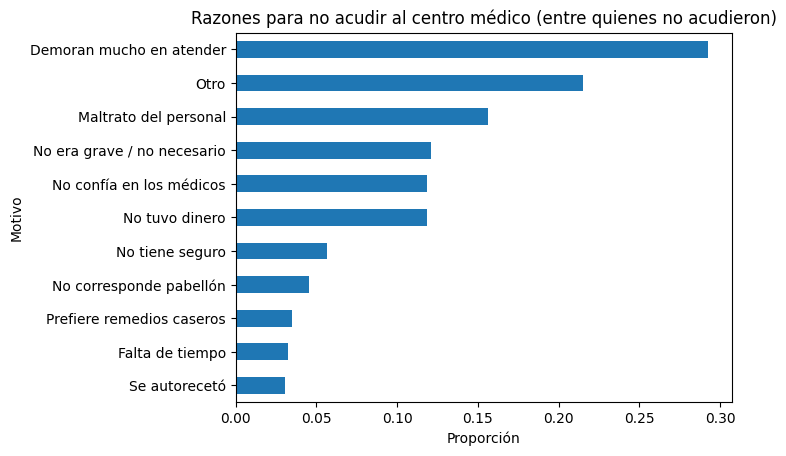

In [ ]:
#Selección de variables de interés
cols_p311 = [col for col in cap300.columns
             if col.startswith("P311_") and col != "P311_11ESP"]
#Filtrado de la población
no_acudieron = cap300[cap300["P310"] == 2]
#Cálculo de conteos
conteo_p311 = no_acudieron[cols_p311].sum()
#Cálculo de proporciones
conteo_prop = conteo_p311 / len(no_acudieron)
#Recodificación de etiquetas
labels_p311 = {
    "P311_1": "No tuvo dinero",
    "P311_2": "Demoran mucho en atender",
    "P311_3": "No confía en los médicos",
    "P311_4": "No era grave / no necesario",
    "P311_5": "Prefiere remedios caseros",
    "P311_6": "No tiene seguro",
    "P311_7": "Se autorecetó",
    "P311_8": "Falta de tiempo",
    "P311_9": "Maltrato del personal",
    "P311_10": "No corresponde pabellón",
    "P311_11": "Otro"
}
conteo_prop.index = conteo_prop.index.map(labels_p311)
#Ordenamiento
conteo_prop = conteo_prop.sort_values()
#Visualización
import matplotlib.pyplot as plt

conteo_prop.plot(kind="barh")

plt.title("Razones para no acudir al centro médico (entre quienes no acudieron)")
plt.xlabel("Proporción")
plt.ylabel("Motivo")
plt.show()

El primer gráfico indicó que una porción significativa de la población penitenciaria, el 38.0%, ha manifiestado padecer alguna enfermedad dentro del establecimiento, mientras que la mayoría (61.8%) ha reportado no presentar afecciones de salud. Aunque el grupo mayoritario fue declarado sano, la existencia de casi cuatro de cada diez internos con problemas de salud suele revelar una carga epidemiológica considerable para el sistema penitenciario peruano. En el segundo gráfico mostró que la mayoría de la población penitenciaria que requirió servicios de salud, un 78.9%, logró obtener atención médica, mientras que un 21.1% no tuvo acceso a la misma. Aunque la cifra de atención parece alta, la existencia de más de una quinta parte de internos excluidos de servicios de salud básicos reveló brechas importantes en la cobertura sanitaria del sistema penitenciario. Por último, en el tercer gráfico se identificó que las barreras subjetivas e institucionales que impiden el acceso a la salud, destacó la demora en la atención ha sido el motivo principal (proporción cercana al 0.30). Siguiendo en relevancia el maltrato del personal (aprox. 0.15) y factores de desconfianza o falta de recursos económicos, ambos por encima del 0.10.


# 1.4. Datos sobre el ambito laboral de la poblacion penitenciaria

El análisis del ámbito laboral de la población penitenciaria, a partir de su experiencia y tipo de ocupación previa, permitió identificar habilidades, condiciones laborales y factores de vulnerabilidad que pueden influir en sus trayectorias y en sus posibilidades de reinserción social.


In [ ]:
#Recodificación de la variable
labels_p114 = {
    1: "Sí trabajó",
    2: "No trabajó"
}
#Cálculo de porcentajes
tabla_p114 = cap100["P114"].value_counts(normalize=True) * 100
#Aplicación de etiquetas
tabla_p114.index = tabla_p114.index.map(labels_p114)
#Organización de la tabla
tabla_p114 = tabla_p114.reset_index()
tabla_p114.columns = ["Experiencia laboral previa", "Porcentaje (%)"]
#Redondeo de valores
tabla_p114["Porcentaje (%)"] = tabla_p114["Porcentaje (%)"].round(1)

tabla_p114

,Experiencia laboral previa,Porcentaje (%)
0,Sí trabajó,95.60
1,No trabajó,4.40


In [ ]:
#Recodificación de la variable
labels_p117 = {
    1: "Empleador",
    2: "Trabajador dependiente",
    3: "Empleado",
    4: "Obrero",
    5: "Familiar no remunerado",
    6: "Trabajador del hogar",
    7: "Otro"
}
#Cálculo de porcentajes
tabla_p117 = cap100["P117"].value_counts(normalize=True) * 100
#Aplicación de etiquetas
tabla_p117.index = tabla_p117.index.map(labels_p117)
#Organización de la tabla
tabla_p117 = tabla_p117.reset_index()
tabla_p117.columns = ["Tipo de ocupación", "Porcentaje (%)"]
#Redondeo de valores
tabla_p117["Porcentaje (%)"] = tabla_p117["Porcentaje (%)"].round(1)

tabla_p117

,Tipo de ocupación,Porcentaje (%)
0,Obrero,43.40
1,Trabajador dependiente,30.20
2,Empleado,16.20
3,Familiar no remunerado,6.20
4,Empleador,3.30
5,Trabajador del hogar,0.70


La primera tabla mostró que la gran mayoría de la población penitenciaria peruana, un 95.60%, ha contado con experiencia laboral antes de su ingreso al penal, mientras que solo un 4.40% no había trabajado nunca. Y en la segunda tabla detalló que la población penitenciaria con experiencia laboral previa estuvo concentrada mayoritariamente en ocupaciones operativas y de subordinación, donde el perfil de obrero (43.40%) y trabajador dependiente (30.20%) suma casi las tres cuartas partes del total. En contraste, las categorías asociadas a mayor autonomía o gestión, como empleado (16.20%) y empleador (3.30%), presentaron una participación minoritaria.


# 1.5. Dato sobre el nivel educativo de la poblacion penitenciaria

El análisis del nivel educativo de la población penitenciaria permitió identificar habilidades, desigualdades y factores de exclusión que pueden influir en sus trayectorias y en sus posibilidades de reinserción social.


In [ ]:
labels_p104 = {
    1: "Sin nivel",
    2: "Inicial",
    3: "Primaria incompleta",
    4: "Primaria completa",
    5: "Secundaria incompleta",
    6: "Secundaria completa",
    7: "Superior no universitaria incompleta",
    8: "Superior no universitaria completa",
    9: "Superior universitaria incompleta",
    10: "Superior universitaria completa",
    11: "Postgrado"
}

tabla_p104 = cap100["P104_1"].value_counts(normalize=True) * 100
tabla_p104.index = tabla_p104.index.map(labels_p104)

tabla_p104 = tabla_p104.reset_index()
tabla_p104.columns = ["Nivel educativo", "Porcentaje (%)"]

tabla_p104["Porcentaje (%)"] = tabla_p104["Porcentaje (%)"].round(1)

tabla_p104

,Nivel educativo,Porcentaje (%)
0,Secundaria incompleta,32.60
1,Secundaria completa,27.40
2,Primaria incompleta,15.90
3,Primaria completa,9.30
4,Superior no universitaria completa,3.80
5,Superior no universitaria incompleta,3.50
6,Superior universitaria incompleta,2.80
7,Sin nivel,2.30
8,Superior universitaria completa,2.30
9,Inicial,0.10


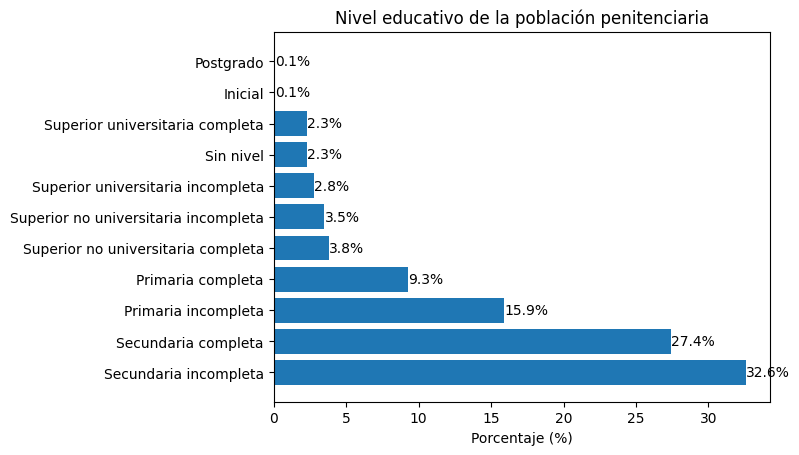

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.barh(tabla_p104["Nivel educativo"], tabla_p104["Porcentaje (%)"])

plt.title("Nivel educativo de la población penitenciaria")
plt.xlabel("Porcentaje (%)")

for i, v in enumerate(tabla_p104["Porcentaje (%)"]):
    plt.text(v, i, f"{v}%", va='center')

plt.show()

El gráfico de barras horizontales reveló que la población penitenciaria peruana presentó un bajo nivel de capital educativo formal, concentrándose mayoritariamente en la educación básica. El grupo más representativo fue aquel con secundaria incompleta (32.6%), seguido por quienes sí lograron culminar dicho nivel (27.4%). También, se pudo observar que el 25.2% de los internos apenas alcanzó algún grado de instrucción primaria (completa o incompleta), mientras que el acceso a la educación superior (universitaria y no universitaria) fue residual, sumando menos del 13% entre todas sus variantes.


# 1.6. Conclusiones

El análisis de la dimensión sociodemográfica de la población del sistema penitenciario peruano puede permitir concluir que el proceso de reinserción puede verse condicionado por una interacción entre la desigualdad estructural preexistente y las deficiencias del entorno institucional.
En primer lugar, el capital humano y laboral, se identificó que la población penitenciaria posee una trayectoria laboral activa previa al encierro (95.6%), concentrada principalmente en el sector de obreros y trabajadores dependientes (73.6%). No obstante, este capital laboral suele ser frágil teniendo en cuenta el bajo capital cultural educativo, donde el 32.6% no culminó la secundaria y un 25.2% apenas alcanzó la instrucción primaria.
En segundo lugar,  el factor entre la infraestructura penitenciaria y la población privada de libertad, mostró hallazgos sobre la percepción “negativa” sobre la calidad de los alimentos (59.2% mala/muy mala) y las deficiencias en la limpieza de servicios higiénicos (44.5% insatisfacción). Sugiriendo un entorno de reclusión condicionado por la precariedad física, sumadas a una carga de morbilidad del 38.0%.
En tercer lugar, el acceso a la Salud, mostró que aunque el acceso a la atención médica reportado es mayoritario (78.9%), las razones para la no asistencia revelan ciertas fallas cualitativas complejas. Por ejemplo, la demora en la atención y el maltrato del personal suelen emerger como los principales obstáculos subjetivos.
Y por último, la estructura demográfica reveló un sistema poblacional masculino (94.0%) y joven (más del 50% menor de 35 años). lo que ha revelado una concentración en edades productivas. Asimismo, la reducida presencia femenina (6.0%) puede plantear la posibilidad de un riesgo de invisibilización operativa, donde los programas de "preparación" podrían estar estandarizados bajo lógicas masculinas.


# 2. Factores asociados al proceso de reinsercion social


En este segundo apartado se analizó los factores que pueden condicionar el proceso de reinserción social de la población privada de libertad. A diferencia del primer panorama, centrado en las características sociodemográficas y las condiciones materiales del sistema penitenciario, esta sección puso énfasis en dimensiones vinculadas a las oportunidades de desarrollo personal, las barreras estructurales y las capacidades institucionales. Para ello, se consideraron variables relacionadas con la participación en programas educativos y laborales, las motivaciones y expectativas frente al trabajo, así como las razones que limitan el acceso a dichas actividades. Asimismo, se llego a incorporar elementos asociados a la salud, la experiencia de discriminación y la presencia de redes de apoyo, entendidas como factores que pueden facilitar o restringir la reintegración social. Finalmente, se incluyó la evaluación de los servicios brindados dentro del establecimiento penitenciario y las expectativas de futuro de las personas internas, con el fin de comprender de manera integral las condiciones que influyen en sus posibilidades de reinserción.


# 2.1. Acceso y calidad de los servicios penitenciarios

Se construyó un indicador que combina el acceso y la calidad percibida de los servicios ofrecidos dentro del establecimiento penitenciario. Esto incluyó psicología, servicio social, salud y trabajo. Además, este enfoque tuvo la intención de permitir evaluar la capacidad institucional no solo en términos de cobertura, sino también de efectividad percibida, considerando que la calidad de los servicios puede ser un elemento clave en los procesos de reinserción social.


In [ ]:
import pandas as pd
#Colocando etiquetas
servicios_acceso = {
    "Psicología": ("P312_1", "P312B_1"),
    "Servicio social": ("P312_2", "P312B_2"),
    "Salud": ("P312_3", "P312B_3"),
    "Trabajo": ("P312_5", "P312B_5")
}

resultados = []

for nombre, (var_acceso, var_calidad) in servicios_acceso.items():


    #Acceso (toda la muestra)

    acceso = cap300[var_acceso].value_counts(normalize=True) * 100
    accede = acceso.get(1, 0)
    no_accede = acceso.get(2, 0)


    #Filtrar solo quienes acceden

    df_acc = cap300[cap300[var_acceso] == 1]


    #Calidad (solo quienes acceden)

    calidad = df_acc[var_calidad].value_counts(normalize=True) * 100

    buena = calidad.get(3, 0) + calidad.get(4, 0)
    mala = calidad.get(1, 0) + calidad.get(2, 0)

    resultados.append({
        "Servicio": nombre,
        "Accede (%)": round(accede, 1),
        "No accede (%)": round(no_accede, 1),
        "Buena/Muy buena (%)": round(buena, 1),
        "Mala/Muy mala (%)": round(mala, 1)
    })

tabla_servicios_acceso = pd.DataFrame(resultados)
tabla_servicios_acceso

,Servicio,Accede (%),No accede (%),Buena/Muy buena (%),Mala/Muy mala (%)
0,Psicología,75.20,24.50,95.00,4.40
1,Servicio social,49.60,49.70,93.00,6.30
2,Salud,52.10,47.20,72.90,26.30
3,Trabajo,54.50,44.90,95.50,3.90


En relación con el acceso a los servicios dentro del establecimiento penitenciario, se observó diferencias entre las distintas áreas. El servicio de psicología presentó el mayor nivel de acceso (75.2%), en contraste con el servicio social, donde el acceso alcanzó solo al 49.6% de la población, evidenciando una brecha en cobertura. De manera similar, los servicios de salud (52.1%) y trabajo (54.5%) mostraron niveles intermedios de acceso, cercanos a la mitad de la población. En cuanto a la calidad percibida, se ha registrado un patrón diferenciado: mientras los servicios de psicología (95.0%) y trabajo (95.5%) concentraron valoraciones mayoritariamente positivas, el servicio de salud presentó una proporción considerablemente menor de evaluaciones favorables (72.9%) y el nivel más alto de valoraciones negativas (26.3%). Este contraste resaltó frente a los demás servicios, que mantienen niveles bajos de insatisfacción. Por su parte, el servicio social, a pesar de su menor cobertura, presentó una valoración positiva elevada (93.0%) entre quienes acceden.


# 2.2 Motivaciones para la participación en talleres laborales

Para comprender el sentido que las personas privadas de libertad atribuyen a su participación en los talleres laborales, se analizó la variable de motivación para participar en dichas actividades. Esta variable puede permitir identificar si la participación responde a intereses formativos, como el aprendizaje de un oficio, o si puede estar orientada a beneficios instrumentales o al uso del tiempo dentro del establecimiento. A través de esta aproximación, posibilita la opción de distinguir diferentes formas de involucramiento en los programas laborales, lo cual puede resultar relevante para evaluar en qué medida estas actividades suelen contribuir al desarrollo de capacidades vinculadas a la reinserción social.


In [ ]:
labels_p306 = {
    1: "Aprender un oficio",
    2: "Obtener beneficios",
    3: "Pasar el tiempo",
    4: "Otro"
}

tabla_p306 = cap300["P306"].value_counts(normalize=True) * 100
tabla_p306.index = tabla_p306.index.map(labels_p306)

tabla_p306 = tabla_p306.reset_index()
tabla_p306.columns = ["Motivación", "Porcentaje (%)"]

tabla_p306["Porcentaje (%)"] = tabla_p306["Porcentaje (%)"].round(1)

tabla_p306

,Motivación,Porcentaje (%)
0,Aprender un oficio,53.80
1,Obtener beneficios,37.10
2,Pasar el tiempo,8.00
3,Otro,1.10


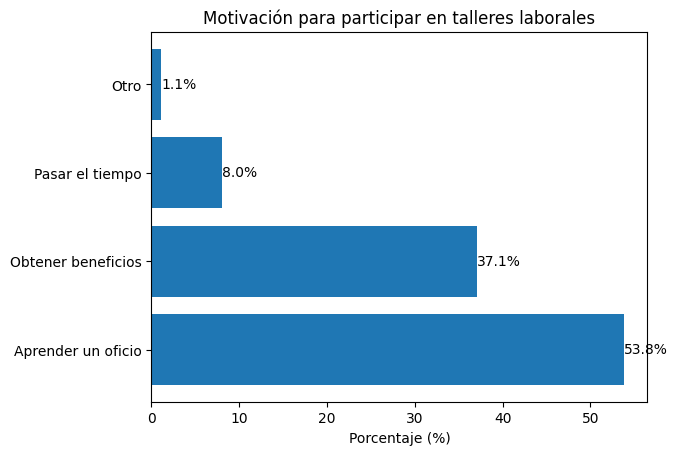

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.barh(tabla_p306["Motivación"], tabla_p306["Porcentaje (%)"])

plt.title("Motivación para participar en talleres laborales")
plt.xlabel("Porcentaje (%)")

# Mostrar valores en las barras
for i, v in enumerate(tabla_p306["Porcentaje (%)"]):
    plt.text(v, i, f"{v}%", va='center')

plt.show()

En relación con las motivaciones para participar en talleres laborales, se observó que la principal razón señalada por la población privada de libertad ha sido el aprendizaje de un oficio, con un 53.8%. En segundo lugar, el 37.1% indicó que participa con el objetivo de obtener beneficios, mientras que un 8.0% señaló que lo hace para pasar el tiempo dentro del establecimiento. Finalmente, un 1.1% mencionaron otras motivaciones. En conjunto, los resultados mostraron que más de la mitad de la población suele asociar su participación en talleres con una finalidad formativa, mientras que una proporción importante también suele vincularse a incentivos específicos dentro del sistema penitenciario.


# 2.2.1. Barreras para la participación en actividades laborales

Se busco profundizar en las limitaciones que enfrentan las personas privadas de libertad en el acceso a actividades laborales dentro del establecimiento penitenciario, se incorporó la variable referida a las razones por las cuales no realizan ningún tipo de trabajo. Esta variable puede permitir identificar no solo la ausencia de participación laboral, sino también los factores que la explican, diferenciando entre aspectos vinculados a la oferta institucional —como la falta de oportunidades, materiales o condiciones adecuadas— y factores asociados a decisiones o condiciones individuales. En este sentido, el análisis de estas razones puede ser una opción clave para comprender las barreras estructurales que pueden restringir el desarrollo de capacidades laborales, elemento fundamental en los procesos de reinserción social.


In [ ]:
labels_p314 = {
    1: "No le ofrecen trabajo",
    2: "No le gustan los trabajos",
    3: "Estudia",
    4: "No tiene dinero para el taller",
    5: "No es rentable",
    6: "Falta de materiales",
    7: "Otros",
    8: "No sabe",
    9: "Recién ingresó",
    10: "Problemas de salud"
}

tabla_p314 = cap300["P314"].value_counts(normalize=True) * 100
tabla_p314.index = tabla_p314.index.map(labels_p314)

tabla_p314 = tabla_p314.reset_index()
tabla_p314.columns = ["Motivo para no trabajar", "Porcentaje (%)"]

tabla_p314["Porcentaje (%)"] = tabla_p314["Porcentaje (%)"].round(1)

tabla_p314.sort_values(by="Porcentaje (%)", ascending=False)

,Motivo para no trabajar,Porcentaje (%)
0,No sabe,23.30
1,Otros,16.50
2,Recién ingresó,13.60
3,No le gustan los trabajos,10.30
4,Problemas de salud,8.60
5,No es rentable,8.30
6,No le ofrecen trabajo,7.00
7,No tiene dinero para el taller,5.60
8,Estudia,4.50
9,Falta de materiales,2.40


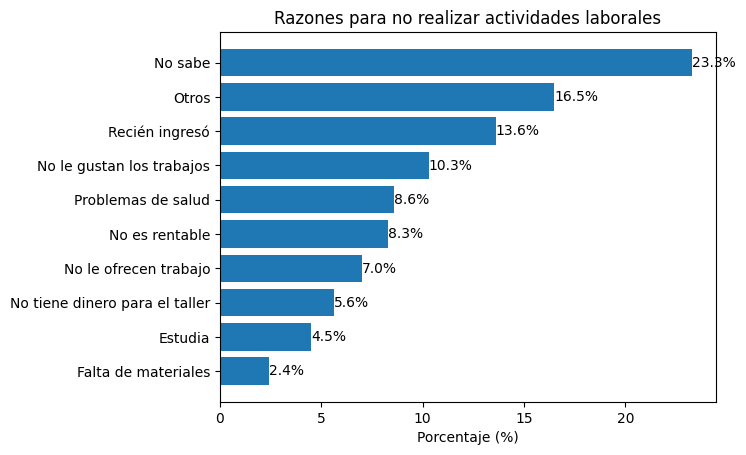

In [ ]:
tabla_p314 = tabla_p314.sort_values(by="Porcentaje (%)")

plt.figure()

plt.barh(tabla_p314["Motivo para no trabajar"], tabla_p314["Porcentaje (%)"])

plt.title("Razones para no realizar actividades laborales")
plt.xlabel("Porcentaje (%)")

for i, v in enumerate(tabla_p314["Porcentaje (%)"]):
    plt.text(v, i, f"{v}%", va='center')

plt.show()

Para las razones por las cuales la población privada de libertad no participa en actividades laborales, se observó que la categoría más frecuente corresponde a quienes no especifican un motivo (23.3%), seguida por la opción “otros” (16.5%) y por aquellos que señalaron haber ingresado recientemente al establecimiento penitenciario (13.6%). En un segundo nivel, se identificaron motivos vinculados a la valoración del trabajo y a condiciones personales, como el desinterés por los trabajos ofrecidos (10.3%) y los problemas de salud (8.6%). En contraste, factores directamente asociados a limitaciones estructurales del sistema, como la falta de oferta laboral (7.0%), la necesidad de contar con recursos económicos para acceder a talleres (5.6%) o la carencia de materiales (2.4%), presentaron proporciones menores frente a otros.


# 2.2.2. Expectativas sobre la reinsercion laboral

Con el fin de aproximarse a las expectativas de reinserción laboral de la población privada de libertad, se analizó la percepción sobre la utilidad de los programas desarrollados dentro del establecimiento penitenciario para conseguir empleo o generar ingresos una vez en libertad. Esta variable permitió explorar el nivel de confianza que las personas internas depositan en dichas iniciativas, así como su valoración respecto a la efectividad de estos espacios en la preparación para la vida fuera del penal. En este sentido, la expectativa laboral puede permitir constituir un indicador relevante para comprender no solo las oportunidades objetivas de reinserción, sino también las percepciones subjetivas que pueden influir en la disposición y el involucramiento en estos programas.


In [ ]:
labels_p307 = {
    1: "Sí cree que ayudará",
    2: "No cree",
    3: "No sabe"
}

tabla_p307 = cap300["P307"].value_counts(normalize=True) * 100
tabla_p307.index = tabla_p307.index.map(labels_p307)

tabla_p307 = tabla_p307.reset_index()
tabla_p307.columns = ["Expectativa laboral", "Porcentaje (%)"]

tabla_p307["Porcentaje (%)"] = tabla_p307["Porcentaje (%)"].round(1)

tabla_p307

,Expectativa laboral,Porcentaje (%)
0,Sí cree que ayudará,93.00
1,No cree,3.50
2,No sabe,3.50


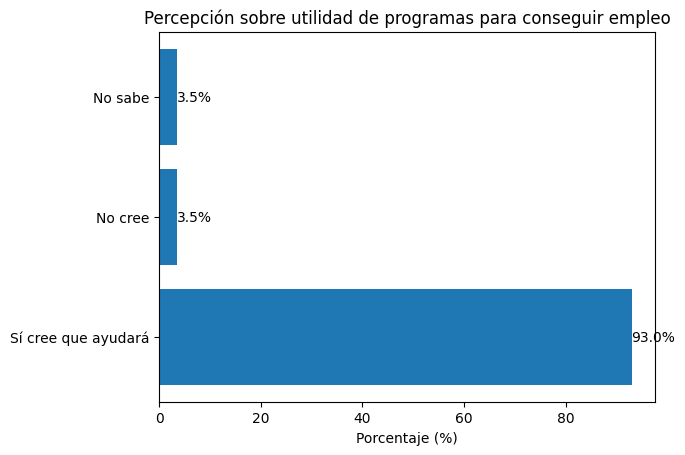

In [ ]:
plt.figure()

plt.barh(tabla_p307["Expectativa laboral"], tabla_p307["Porcentaje (%)"])

plt.title("Percepción sobre utilidad de programas para conseguir empleo")
plt.xlabel("Porcentaje (%)")

for i, v in enumerate(tabla_p307["Porcentaje (%)"]):
    plt.text(v, i, f"{v}%", va='center')

plt.show()

En relación con las expectativas sobre la reinserción laboral, se observó que una amplia mayoría de la población privada de libertad (93.0%) consideró que los programas desarrollados dentro del establecimiento penitenciario les puede permitir conseguir empleo o generar ingresos una vez en libertad. En contraste, un 3.5% señaló que no cree que estos programas contribuyan a dicho objetivo, mientras que otro 3.5% manifestó no tener una opinión definida al respecto. En conjunto, los resultados suelen mostrar un predominio claro de percepciones positivas sobre la utilidad de estos programas en términos de inserción laboral futura.


# 2.3. Participación educativa y barreras de acceso a la formación

Con el objetivo de analizar el rol de la formación educativa en el proceso de reinserción social, se incorporó la variable de participación en programas educativos dentro del establecimiento penitenciario, así como las principales razones que pueden limitar el acceso a estos espacios. Este enfoque permitió no solo identificar el nivel de involucramiento de la población privada de libertad en actividades formativas, sino también comprender las barreras que dificultan su acceso, ya sean de carácter institucional, personal o estructural. En este sentido, la educación puede permitir constituir un componente clave para el desarrollo de capacidades y la ampliación de oportunidades futuras, por lo que el análisis conjunto de participación y restricciones puede permitir aproximarse de manera más integral a las condiciones que suelen influir en los procesos de reinserción social.


In [ ]:
labels_p303 = {
    1: "Sí estudia",
    2: "No estudia"
}

tabla_p303 = cap300["P303"].value_counts(normalize=True) * 100
tabla_p303.index = tabla_p303.index.map(labels_p303)

tabla_p303 = tabla_p303.reset_index()
tabla_p303.columns = ["Participación educativa", "Porcentaje (%)"]

tabla_p303["Porcentaje (%)"] = tabla_p303["Porcentaje (%)"].round(1)

tabla_p303

,Participación educativa,Porcentaje (%)
0,No estudia,74.30
1,Sí estudia,25.70


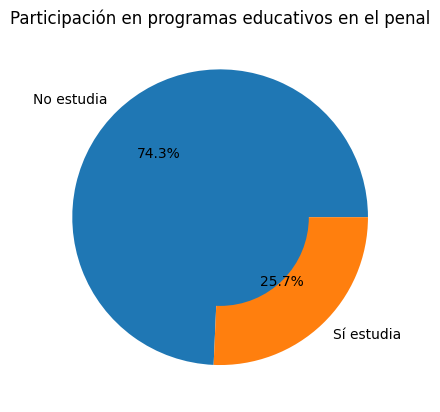

In [ ]:
plt.figure()

plt.pie(
    tabla_p303["Porcentaje (%)"],
    labels=tabla_p303["Participación educativa"],
    autopct='%1.1f%%'
)

# efecto donut
centre_circle = plt.Circle((0,0), 0.60)
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Participación en programas educativos en el penal")

plt.show()

In [ ]:
# Filtrar quienes NO estudian
no_estudian = cap300[cap300["P303"] == 2]

labels_p308 = {
    1: "No hay programas adecuados",
    2: "No le interesan",
    3: "Trabaja",
    4: "No hay vacantes",
    5: "Otros",
    6: "No sabe",
    7: "Recién ingresó / está por salir",
    8: "Problemas económicos",
    9: "Problemas de salud",
    10: "Falta de beneficios"
}

tabla_p308 = no_estudian["P308"].value_counts(normalize=True) * 100
tabla_p308.index = tabla_p308.index.map(labels_p308)

tabla_p308 = tabla_p308.reset_index()
tabla_p308.columns = ["Motivo para no estudiar", "Porcentaje (%)"]

tabla_p308["Porcentaje (%)"] = tabla_p308["Porcentaje (%)"].round(1)

tabla_p308.sort_values(by="Porcentaje (%)", ascending=False)

,Motivo para no estudiar,Porcentaje (%)
0,Trabaja,53.20
1,No hay vacantes,9.10
2,No sabe,8.30
3,No le interesan,7.80
4,No hay programas adecuados,6.30
5,Otros,6.30
6,Recién ingresó / está por salir,4.10
7,Problemas económicos,3.10
8,Problemas de salud,1.10
9,Falta de beneficios,0.80


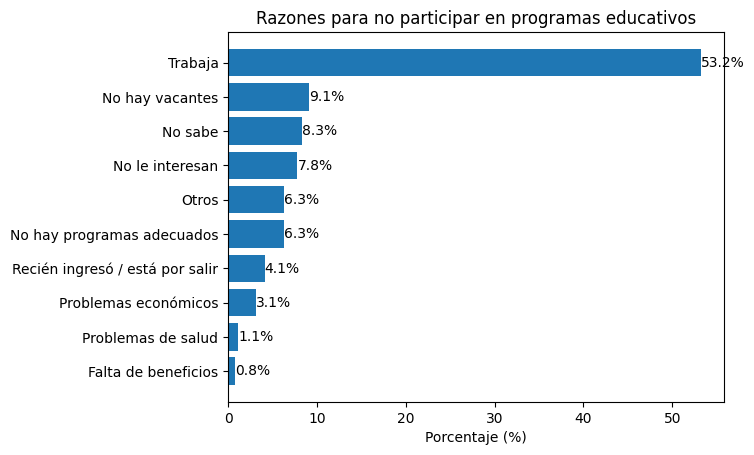

In [ ]:
import matplotlib.pyplot as plt

tabla_p308 = tabla_p308.sort_values(by="Porcentaje (%)")

plt.figure()

plt.barh(tabla_p308["Motivo para no estudiar"], tabla_p308["Porcentaje (%)"])

plt.title("Razones para no participar en programas educativos")
plt.xlabel("Porcentaje (%)")

for i, v in enumerate(tabla_p308["Porcentaje (%)"]):
    plt.text(v, i, f"{v}%", va='center')

plt.show()

En relación con la participación en programas educativos dentro del establecimiento penitenciario, se destacó que una amplia mayoría de la población privada de libertad no se encuentra estudiando (74.3%), frente a un 25.7% que sí participa en estas actividades. Al examinar las razones de no participación, resaltó de manera particular que más de la mitad de quienes no estudian señalan que esto se debe a que trabajan (53.2%), constituyéndose en el motivo predominante. En contraste, otros factores presentaron proporciones menores, como la falta de vacantes (9.1%), la ausencia de una respuesta definida (8.3%) y el desinterés por los programas educativos (7.8%). Asimismo, razones vinculadas a la oferta institucional, como la falta de programas adecuados (6.3%), aparecieron con menor peso. Finalmente, motivos como problemas económicos, de salud o la falta de beneficios penitenciarios registran niveles bajos dentro del conjunto de respuestas.


# 2.4. Redes de apoyo y vinculo familiar

Con el fin de analizar el papel de las redes sociales en el proceso de reinserción, se incorporó la variable referida al tipo de visitas que reciben las personas privadas de libertad dentro del establecimiento penitenciario. Esta variable permitió aproximarse a la presencia de vínculos familiares y sociales activos, los cuales pueden constituir una fuente potencial de apoyo emocional, económico y social. En este sentido, las visitas representaron un indicador que puede ser relevante del grado de conexión con el entorno externo, elemento que puede incidir en las oportunidades de reintegración una vez en libertad. Por último, este análisis del tipo de vínculo en las visitas puede ser una opción para permitir, además, identificar figuras de soporte dentro de la red social de las personas internas.


In [ ]:
labels_p316 = {
    1: "Padre/padrastro",
    2: "Madre/madrasta",
    3: "Hijos(as)",
    4: "Pareja",
    5: "Hermanos(as)",
    6: "Abuelos(as)",
    7: "Tíos(as)",
    8: "Amigos(as)",
    9: "Otros",
    10: "Ambos padres"
}


conteo_p316 = cap300["P316"].value_counts(normalize=True) * 100


conteo_p316.index = conteo_p316.index.map(labels_p316)


tabla_p316 = conteo_p316.reset_index()
tabla_p316.columns = ["Tipo de visita", "Porcentaje (%)"]


tabla_p316["Porcentaje (%)"] = tabla_p316["Porcentaje (%)"].round(1)

tabla_p316.sort_values(by="Porcentaje (%)", ascending=False)

,Tipo de visita,Porcentaje (%)
0,Pareja,33.80
1,Madre/madrasta,32.70
2,Hermanos(as),14.10
3,Hijos(as),7.20
4,Padre/padrastro,5.30
5,Otros,2.80
6,Tíos(as),1.70
7,Amigos(as),1.10
8,Abuelos(as),0.70
9,Ambos padres,0.50


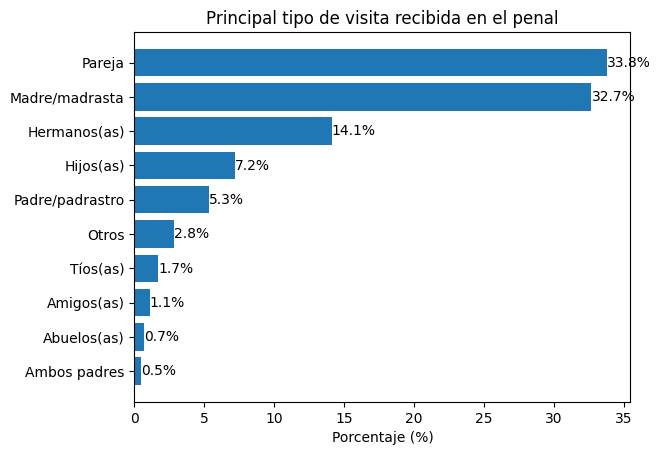

In [ ]:
import matplotlib.pyplot as plt

tabla_p316 = tabla_p316.sort_values(by="Porcentaje (%)")

plt.figure()

plt.barh(tabla_p316["Tipo de visita"], tabla_p316["Porcentaje (%)"])

plt.title("Principal tipo de visita recibida en el penal")
plt.xlabel("Porcentaje (%)")

for i, v in enumerate(tabla_p316["Porcentaje (%)"]):
    plt.text(v, i, f"{v}%", va='center')

plt.show()

En relación con el tipo de visitas recibidas por la población privada de libertad, se observó que las principales fuentes de contacto corresponden a la pareja (33.8%) y a la madre o madrasta (32.7%), concentrando ambas más de la mitad de los vínculos reportados. En un segundo nivel, se encontraron los hermanos (14.1%), aunque con una proporción considerablemente menor en comparación con las dos categorías predominantes. En contraste, las visitas de hijos(as) (7.2%) y padre o padrastro (5.3%) presentan niveles más reducidos. Asimismo, otros tipos de vínculos, como tíos(as) (1.7%), amigos(as) (1.1%), abuelos(as) (0.7%) y ambos padres (0.5%), llegaron a registrar porcentajes bajos. Este patrón evidenció una concentración de las visitas en vínculos cercanos específicos, mientras que el resto de relaciones sociales presentaron una participación notablemente menor.


# 2.5. Percepción de discriminación en el establecimiento penitenciario

Con el propósito de incorporar la dimensión del clima social dentro del establecimiento penitenciario, se analizó la variable referida a la percepción de discriminación experimentada por la población privada de libertad. Esta variable posibilita aproximarse a las formas de trato y a las dinámicas de interacción que pueden desarrollarse al interior del penal, las cuales pueden influir en la experiencia cotidiana de las personas internas. En este sentido, la percepción de discriminación constituyó un indicador relevante de posibles desigualdades y tensiones dentro del entorno institucional, que pueden afectar tanto el bienestar de la población como sus condiciones para el desarrollo de procesos de reinserción social.


In [ ]:
labels_p317 = {
    1: "Sí",
    2: "No"
}

tabla_p317 = cap300["P317"].value_counts(normalize=True) * 100
tabla_p317.index = tabla_p317.index.map(labels_p317)

tabla_p317 = tabla_p317.reset_index()
tabla_p317.columns = ["Percepción de discriminación", "Porcentaje (%)"]

tabla_p317["Porcentaje (%)"] = tabla_p317["Porcentaje (%)"].round(1)

tabla_p317

,Percepción de discriminación,Porcentaje (%)
0,No,82.20
1,Sí,17.80


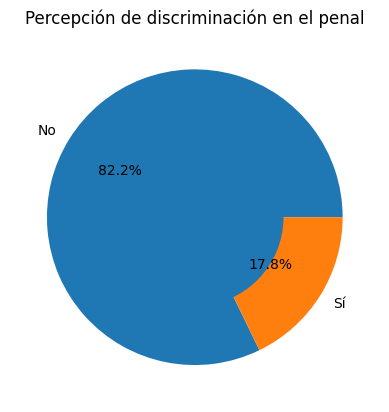

In [ ]:
plt.figure()

plt.pie(
    tabla_p317["Porcentaje (%)"],
    labels=tabla_p317["Percepción de discriminación"],
    autopct='%1.1f%%'
)

centre_circle = plt.Circle((0,0), 0.60)
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Percepción de discriminación en el penal")

plt.show()

En relación con la percepción de discriminación dentro del establecimiento penitenciario, se observó que la mayoría de la población privada de libertad (82.2%) ha señalado no haber experimentado este tipo de trato. En contraste, un 17.8% indicó que sí se ha sentido discriminado durante su permanencia en el penal. Si bien la proporción de respuestas negativas suele verse claramente predominante, la presencia de un grupo no menor que reporta experiencias de discriminación puede evidenciar la existencia de percepciones diferenciadas en cuanto al trato recibido dentro del entorno institucional.


# 2.6. Expectativas de reinserción y proyección de vida al egreso

Para complementar el análisis de los factores asociados a la reinserción social, se incorporó la variable referida a las expectativas de la población privada de libertad sobre lo que planea realizar al momento de salir del establecimiento penitenciario. Esta variable puede permitir aproximarse a la dimensión subjetiva del proceso de reinserción, en tanto recoge las aspiraciones, metas y orientaciones hacia el futuro de las personas internas. A diferencia de otras variables que suelen estar centradas en condiciones estructurales o en la participación en programas dentro del penal. Esta medida permitió ofrecer información sobre la capacidad de proyectarse más allá del encierro, lo cual puede constituir un elemento clave para comprender los procesos de cambio y las posibilidades de reintegración social. En este sentido, los planes de estudiar, trabajar u otras alternativas permiten identificar horizontes de acción que pueden estar asociados a distintos niveles de preparación, motivación y expectativas frente al retorno a la sociedad.


In [ ]:
cols_p403 = ["P403_1", "P403_2", "P403_3", "P403_4", "P403_5"]
conteo_p403 = cap400[cols_p403].sum()
conteo_p403 = conteo_p403 / len(cap400) * 100
labels_p403 = {
    "P403_1": "Estudiar",
    "P403_2": "Trabajar",
    "P403_3": "Viajar",
    "P403_4": "Retornar a su país",
    "P403_5": "Otros"
}

conteo_p403.index = conteo_p403.index.map(labels_p403)
tabla_p403 = conteo_p403.reset_index()
tabla_p403.columns = ["Plan al salir", "Porcentaje (%)"]

tabla_p403["Porcentaje (%)"] = tabla_p403["Porcentaje (%)"].round(1)

tabla_p403.sort_values(by="Porcentaje (%)", ascending=False)

,Plan al salir,Porcentaje (%)
1,Trabajar,92.40
0,Estudiar,13.40
2,Viajar,4.90
4,Otros,1.90
3,Retornar a su país,1.40


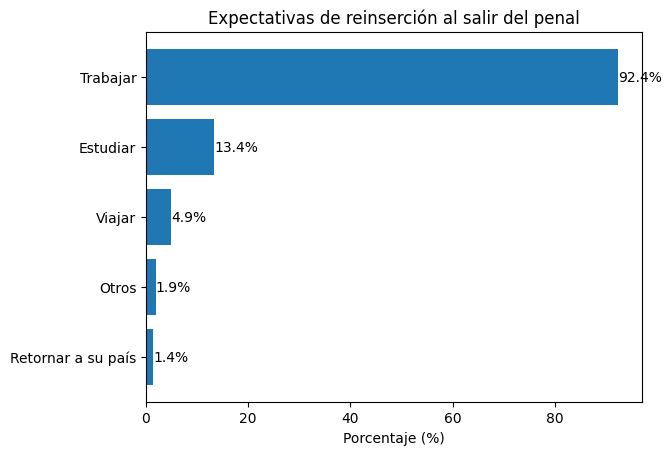

In [ ]:
import matplotlib.pyplot as plt

tabla_p403 = tabla_p403.sort_values(by="Porcentaje (%)")

plt.figure()

plt.barh(tabla_p403["Plan al salir"], tabla_p403["Porcentaje (%)"])

plt.title("Expectativas de reinserción al salir del penal")
plt.xlabel("Porcentaje (%)")

for i, v in enumerate(tabla_p403["Porcentaje (%)"]):
    plt.text(v, i, f"{v}%", va='center')

plt.show()

Las expectativas de la población privada de libertad sobre lo que planea realizar al momento de salir del establecimiento penitenciario, se observó un claro predominio de la opción trabajar, mencionada por el 92.4% de los internos. En contraste, una proporción considerablemente menor señaló la intención de estudiar (13.4%). Otras alternativas, como viajar (4.9%), realizar otras actividades (1.9%) o retornar a su país (1.4%), registraron porcentajes bajos dentro del conjunto de respuestas. En términos generales, los resultados evidenciaron una fuerte orientación hacia la inserción laboral como principal expectativa al egreso, mientras que otras opciones aparecen de manera secundaria y con menor peso relativo.


# 2.7. Conclusiones

En conjunto, los resultados evidenciaron que el proceso de reinserción social de la población privada de libertad se suele configurar en un escenario marcado por tensiones entre oportunidades, limitaciones estructurales y disposiciones individuales. Por un lado, se observa la existencia de condiciones relativamente favorables, como una alta valoración de los servicios penitenciarios —especialmente en las áreas de psicología y trabajo— y una percepción positiva sobre la utilidad de los programas para la inserción laboral futura. Asimismo, la participación en talleres laborales puede verse motivada por el aprendizaje de un oficio, lo que sugiere la presencia de orientaciones hacia la adquisición de capacidades productivas.
Sin embargo, estas condiciones suelen coexistir con restricciones que pueden limitar el proceso de reintegración social. En esto, destaca la baja participación en programas educativos, así como la presencia de barreras para el acceso al trabajo dentro del penal, muchas de las cuales no solo pueden ser explicadas por factores estructurales, sino también por la una posible falta de claridad en los motivos de no participación. A ello se suma una cobertura desigual en los servicios institucionales y una evaluación menos favorable del servicio de salud en comparación con otras áreas.
Y en el plano relacional, si bien se identificaron redes de apoyo activas —principalmente vinculadas a la pareja y la madre—, estas se encuentran concentradas en ciertos vínculos, lo que podría reflejar una limitada diversidad de soporte social. Finalmente, aunque la mayoría no reportó experiencias de discriminación, la existencia de un grupo significativo que sí percibe este tipo de trato puede sugerir la presencia de dinámicas diferenciadas al interior del sistema penitenciario.


# 3. Construcción de un índice de condiciones para la reinserción social

En este tercer apartado se propuso la construcción de un índice sintético orientado a aproximar las condiciones de reinserción social de la población privada de libertad. A diferencia de los análisis previos, centrados en la descripción individual de factores, este enfoque buscó integrar múltiples dimensiones relevantes —educación, motivación laboral, expectativas de inserción, redes de apoyo, salud y barreras estructurales— en una sola medida agregada. Para ello, se operacionalizaron variables dicotómicas que distinguen entre condiciones favorables (como estudiar en el penal, participar en talleres con fines formativos, contar con expectativas laborales positivas y disponer de redes de apoyo) y condiciones adversas (como problemas de salud, ausencia de participación educativa, limitaciones para el trabajo y experiencias de discriminación). A partir de la suma y resta de estos componentes, se construyó un índice que pueda permitir clasificar a la población según niveles relativos de condiciones para la reinserción. Este procedimiento busca facilitar no solo una lectura más integrada del fenómeno, sino también su posterior uso en análisis explicativos, orientados a identificar los factores que inciden en mejores o peores escenarios de reintegración social.


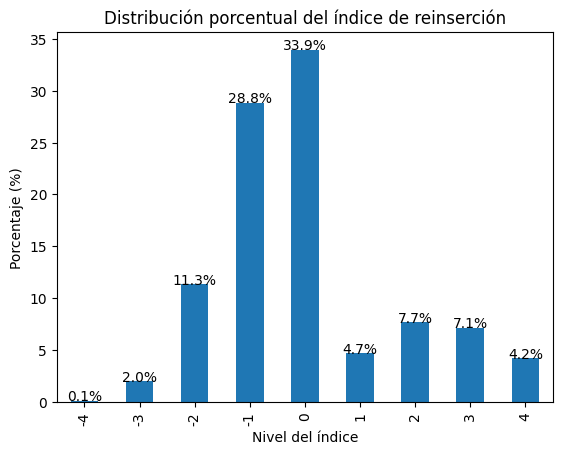

In [ ]:
#Se crea una base de trabajo
df = cap300.copy()
#Construcción de variables (recodificación)
df["edu_activa"] = df["P303"].apply(lambda x: 1 if x == 1 else 0)
df["motivacion_oficio"] = df["P306"].apply(lambda x: 1 if x == 1 else 0)
df["expectativa_laboral"] = df["P307"].apply(lambda x: 1 if x == 1 else 0)
df["redes_apoyo"] = df["P316"].apply(lambda x: 1 if pd.notna(x) else 0)
df["salud_riesgo"] = df["P309"].apply(lambda x: 1 if x == 1 else 0)
df["barrera_educativa"] = df["P303"].apply(lambda x: 1 if x == 2 else 0)
df["barrera_laboral"] = df["P314"].apply(lambda x: 1 if pd.notna(x) else 0)
df["discriminacion"] = df["P317"].apply(lambda x: 1 if x == 1 else 0)
df["indice_reinsercion"] = (         #Construcción del índice de reinserción
    df["edu_activa"] +        #Factores positivos para reinserción
    df["motivacion_oficio"] +
    df["expectativa_laboral"] +
    df["redes_apoyo"]
    -
    df["salud_riesgo"] -       #Factores negativos (barreras)
    df["barrera_educativa"] -
    df["barrera_laboral"] -
    df["discriminacion"]
)
#Distribución del índice
prop_indice = df["indice_reinsercion"].value_counts(normalize=True).sort_index() * 100
#Gráfico
prop_indice.plot(kind="bar")

plt.title("Distribución porcentual del índice de reinserción")
plt.xlabel("Nivel del índice")
plt.ylabel("Porcentaje (%)")

for i, v in enumerate(prop_indice):
    plt.text(i, v, f"{v:.1f}%", ha='center')

plt.show()

El índice analizado reveló una distribución con marcada asimetría negativa. Esta tendencia suele manifestarse primordialmente en la prevalencia del déficit y la vulnerabilidad, donde casi la mitad de la muestra (42.2%) presenta un saldo negativo en sus condiciones de reinserción. Dentro de este espectro, se distingue un grupo con vulnerabilidad moderada que representa el 28.8%, caracterizado por enfrentar obstáculos estructurales como problemas de salud o estigma social en relación a sus recursos personales. De manera crítica, un 13.4% de la población suele hallarse en un estado de exclusión multicausal, donde se presenta la acumulación de factores adversos.
De forma complementaria, los datos expusieron un fenómeno de "equilibrio precario" en el valor neutro del índice, el cual constituye la moda de la distribución con un 33.9%. Se puede decir que este valor describe un escenario de neutralización: los factores de impulso, tales como la educación y las redes de apoyo, suelen ser empatados casi simétricamente por barreras como la discriminación y los riesgos de salud.
Finalmente, los resultados permiten identificar un techo estructural de la reinserción, dado que solo una minoría del 23.1% alcanza niveles positivos, y apenas un 4.2% logra situarse en el nivel óptimo.


# 4. Análisis explicativo de los factores asociados a la expectativa de reinserción laboral

En este cuarto apartado se desarrolló un análisis explicativo orientado a identificar los factores que pueden influir en la expectativa de reinserción laboral de la población privada de libertad. A diferencia de los apartados anteriores, centrados en la descripción de condiciones y la construcción de un índice agregado, en esta sección se empleó un modelo de regresión logística que pueda permitir estimar la probabilidad de que una persona considere que los programas del establecimiento penitenciario le permitirán acceder a empleo o generar ingresos al egreso. La variable dependiente se operacionalizó de forma dicotómica (tener o no una expectativa positiva), mientras que las variables independientes incluyeron dimensiones clave del proceso de reinserción, como la motivación para participar en talleres, la presencia de redes de apoyo, la situación de salud y la experiencia de discriminación. Este enfoque busca la posibilidad de evaluar de manera simultánea el efecto de múltiples factores, identificando cuáles de ellos se asocian de forma significativa con una mayor o menor expectativa de inserción laboral, aportando así evidencia empírica para comprender los mecanismos que configuran las percepciones de reintegración en contextos penitenciarios.


In [17]:
#Preparación de la base
df = cap300.copy()
#Variable dependiente
df["expectativa"] = df["P307"].apply(lambda x: 1 if x == 1 else 0)
#Variables explicativas (factores)
#df["edu_activa"] = df["P303"].apply(lambda x: 1 if x == 1 else 0)
df["motivacion"] = df["P306"].apply(lambda x: 1 if x == 1 else 0)
df["redes"] = df["P316"].apply(lambda x: 1 if pd.notna(x) else 0)
df["salud"] = df["P309"].apply(lambda x: 1 if x == 1 else 0)
df["discriminacion"] = df["P317"].apply(lambda x: 1 if x == 1 else 0)
#df["mujer"] = df["GENERO"].apply(lambda x: 1 if x == 2 else 0)
import statsmodels.api as sm
#Construcción de la base del modelo
df_modelo = df[[
    "expectativa",
    "motivacion",
    "redes",
    "salud",
    "discriminacion"
]].dropna()
#Definición del modelo
X = df_modelo.drop(columns="expectativa")
X = sm.add_constant(X)

y = df_modelo["expectativa"]
#Estimación del modelo
modelo = sm.Logit(y, X).fit()
#Resultados
print(modelo.summary())

Optimization terminated successfully.
         Current function value: 0.262794
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:            expectativa   No. Observations:                75963
Model:                          Logit   Df Residuals:                    75958
Method:                           MLE   Df Model:                            4
Date:                Sun, 22 Mar 2026   Pseudo R-squ.:                  0.4131
Time:                        15:18:02   Log-Likelihood:                -19963.
converged:                       True   LL-Null:                       -34014.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.8894      0.046    -62.923      0.000      -2.979      -2.799
motivacion       

In [18]:
resultado = modelo.summary2().tables[1]
resultado = resultado[["Coef.", "P>|z|"]]
resultado = resultado.reset_index()
resultado.columns = ["Variable", "Coeficiente", "p-valor"]

resultado

,Variable,Coeficiente,p-valor
0,const,-2.89,0.00
1,motivacion,6.00,0.00
2,redes,0.48,0.00
3,salud,0.10,0.00
4,discriminacion,-0.10,0.01


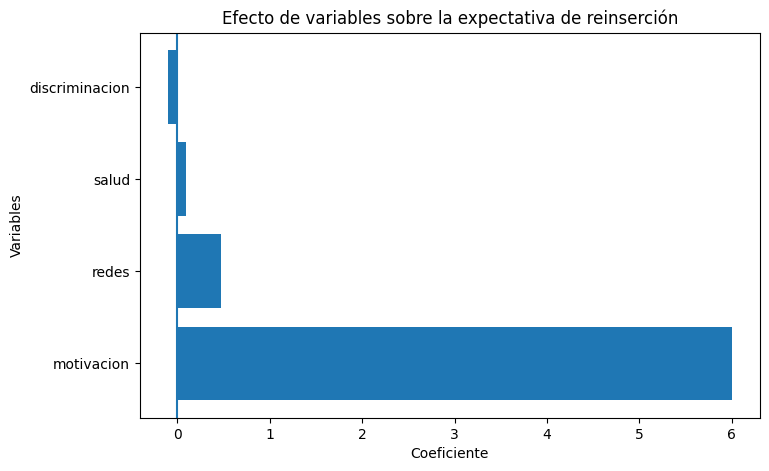

In [19]:
import matplotlib.pyplot as plt

coef = resultado[resultado["Variable"] != "const"]

plt.figure(figsize=(8,5))
plt.barh(coef["Variable"], coef["Coeficiente"])

plt.title("Efecto de variables sobre la expectativa de reinserción")
plt.xlabel("Coeficiente")
plt.ylabel("Variables")

plt.axvline(0)  # línea clave
plt.show()

El modelo presentó una alta solidez estadística, con un Pseudo R-cuadrado de 0.4131. Esto puede significar que las variables seleccionadas (motivación, redes, salud y discriminación) explican aproximadamente el 41.3% de la varianza en la expectativa de reinserción laboral, un valor notablemente alto para estudios de comportamiento humano. Además, el LLR p-value de 0.000 confirma que el modelo ha sido globalmente significativo.

Factores con impacto positivo (impulsores):

Motivación (Coef: 5.9983 | p-valor: 0.000): la variable con mayor peso predictivo. Al ser un coeficiente positivo y elevado, se puede decir que los internos motivados por aprender un oficio tienen una probabilidad mayor de poseer expectativas positivas de reinserción.

Redes de Apoyo (Coef: 0.4791 | p-valor: 0.000): Se puede decir que poseer redes de apoyo (familia, amigos) aumenta la probabilidad de tener expectativas laborales positivas.

Salud (Coef: 0.0988 | p-valor: 0.001): Aunque el efecto es menor comparado con la motivación, es estadísticamente significativo. Se puede decir que un buen estado de salud percibido contribuye positivamente a la visión de futuro laboral, aunque no es el factor determinante por sí solo.

Factores con Impacto Negativo (Barreras):

Discriminación (Coef: -0.0981 | p-valor: 0.009): Esta variable actúa como un freno estructural. De acuerdo al signo negativo del coeficiente, se puede decir que haber experimentado discriminación reduce la probabilidad de tener expectativas laborales positivas.

Finalmente, los resultados del modelo logístico evidenciaron que la expectativa de reinserción laboral no puede distribuirse de manera aleatoria, sino que responde a una estructura de factores subjetivos y sociales. El hallazgo más relevante ha sido la preponderancia de la motivación intrínseca, cuyo coeficiente (beta = 6.00), lo que puede señalar que el deseo de aprendizaje y superación ha sido el predictor más potente de una visión de futuro optimista. No obstante, el modelo también suele advertir sobre el papel de los determinantes externos. Mientras que las redes de apoyo actúan como un factor protector que puede refuerzar la confianza del individuo, la discriminación suele constituirse como una barrera que erosiona sistemáticamente la expectativa de éxito.





# 5. Conclusion del trabajo

En conjunto, los resultados evidenciaron que la reinserción social en el sistema penitenciario peruano no puede entenderse como un proceso exclusivamente individual, sino como un fenómeno estructurado por la interacción entre condiciones institucionales, desigualdades previas y recursos sociales. En línea con Goffman (2001), la experiencia del encierro limita la autonomía y configura trayectorias condicionadas, mientras que, desde la perspectiva de Bourdieu (1997), la disponibilidad de capital social y cultural resulta determinante para las oportunidades de reintegración. Asimismo, como advierte Méndez (2019, 2024), las políticas de reinserción enfrentan límites estructurales que reducen su efectividad. No obstante, los hallazgos también muestran que factores subjetivos como la motivación pueden desempeñar un papel clave, en línea con Maruna (2001), quien resalta el rol de la reconstrucción narrativa del yo. Así como con Ciapessoni (2019), quien ha evidenciado el peso del estigma y la discriminación en la exclusión post-penitenciaria, reflejando que la reinserción se configura en un espacio de tensión entre estructura y agencia.


# Genero

In [16]:
cara_genero = capCARA[["ID_CARATULA", "INTERNO_ID", "GENERO"]]
df = cap300.merge(
    cara_genero,
    on=["ID_CARATULA", "INTERNO_ID"],
    how="left"
)
#df["GENERO"].value_counts(dropna=False)
df["mujer"] = df["GENERO"].apply(lambda x: 1 if x == 2 else 0)
df["expectativa"] = df["P307"].apply(lambda x: 1 if x == 1 else 0)
df["motivacion"] = df["P306"].apply(lambda x: 1 if x == 1 else 0)
df["redes"] = df["P316"].apply(lambda x: 1 if pd.notna(x) else 0)
df["salud"] = df["P309"].apply(lambda x: 1 if x == 1 else 0)
df["discriminacion"] = df["P317"].apply(lambda x: 1 if x == 1 else 0)

df_modelo = df[[
    "expectativa",
    "motivacion",
    "redes",
    "salud",
    "discriminacion",
    "mujer"
]].dropna()

X = df_modelo.drop(columns="expectativa")
X = sm.add_constant(X)

y = df_modelo["expectativa"]

modelo = sm.Logit(y, X).fit()

print(modelo.summary())

Optimization terminated successfully.
         Current function value: 0.262137
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:            expectativa   No. Observations:                75963
Model:                          Logit   Df Residuals:                    75957
Method:                           MLE   Df Model:                            5
Date:                Sun, 22 Mar 2026   Pseudo R-squ.:                  0.4146
Time:                        15:11:23   Log-Likelihood:                -19913.
converged:                       True   LL-Null:                       -34014.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.9186      0.046    -63.323      0.000      -3.009      -2.828
motivacion       

# Bibliografia

Bourdieu, P. (1997). Capital cultural, escuela y espacio social. Siglo xxi. https://books.google.com/books?hl=es&lr=&id=tEibEz6HkwkC&oi=fnd&pg=PA11&dq=pierre+bourdieu+capital+cultural,+escuela+y+espacio+social&ots=shFjFXDgKV&sig=L5hhN1puWy6PuyldPkyzIco1yXY

​Ciapessoni, F. (2019). La prisión y después. Violencia, reingreso y situación de calle. revista de ciencias sociales, 33(47). https://doi.org/10.26489/rvs.v32i45.1

Cale, J., Day, A., Casey, S., Bright, D., Wodak, J., Giles, M., & Baldry, E. (2019). Australian prison vocational education and training and returns to custody among male and female ex-prisoners: A cross-jurisdictional study. Australian and New Zealand Journal of Criminology, 52(1), 129–147. https://doi.org/10.1177/0004865818779418

Cho, R. M., & Tyler, J. H. (2013). Does Prison-Based Adult Basic Education Improve Postrelease Outcomes for Male Prisoners in Florida? Crime and Delinquency, 59(7), 975–1005. https://doi.org/10.1177/0011128710389588

Goffman, E. (2001). Internados: Ensayos sobre la situación social de los enfermos mentales (1a 3d. 3a reimp). Amorrortu.

Galloway, S. (2021). Unseen roots and unfolding flowers? Prison learning, equality and the education of socially excluded groups. British Educational Research Journal, 47(5), 1416–1433. https://doi.org/10.1002/berj.3734

​INEI, MINJUS, & INPE. (2016). Censo Nacional de Población Penitenciaria – 2016. En INEI Microdatos. INEI.

​Méndez, A. P. (2019). Cuidados encerrados: Organización social del cuidado infantil en una prisión femenina de Lima. Pontificia Universidad Católica del Perú.

McNeill, K. M. (2022). A Re-education on How to Work: Vocational Programs in Kingston-Area Prisons, 1950-1965. Labour/ Le Travail, 89, 61–88. https://doi.org/10.52975/llt.2022v89.005

​Méndez, A. P. (2024). La extensión del encierro: experiencias de reinserción laboral de personas que recuperaron su libertad. En J. L. Pérez Guadalupe, V. Lecaros, & L. Nuñovero (Eds.), Las Cárceles en el Perú (pp. 265–320).

Maruna, S. (2001). Making good: How ex-convicts reform and rebuild their lives. American Psychological Association.